## Denoising using Autoencoders

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [6]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

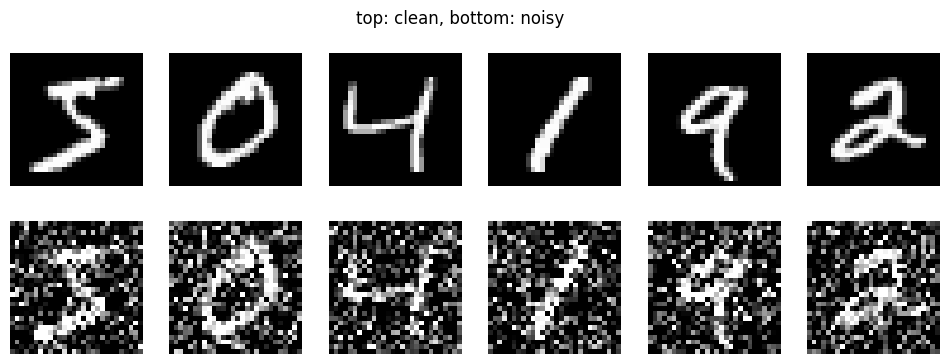

In [7]:
n = 6
plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle('top: clean, bottom: noisy')
plt.show()

In [8]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

In [9]:
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

In [10]:
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,epochs=25,batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 281ms/step - loss: 0.1592 - val_loss: 0.1148
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - loss: 0.1117 - val_loss: 0.1074
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 269ms/step - loss: 0.1063 - val_loss: 0.1036
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 270ms/step - loss: 0.1036 - val_loss: 0.1016
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 268ms/step - loss: 0.1018 - val_loss: 0.1002
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 267ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 268ms/step - loss: 0.0996 - val_loss: 0.0984
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 274ms/step - loss: 0.0987 - val_loss: 0.0977
Epoch 9/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 266ms/step - loss: 0.0981 - val_loss: 0.0973
Epoch 10/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 255ms/step - loss: 0.0976 - val_loss: 0.0969
Epoch 11/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - loss: 0.0971 - val_loss: 0.0968
Epoch 12

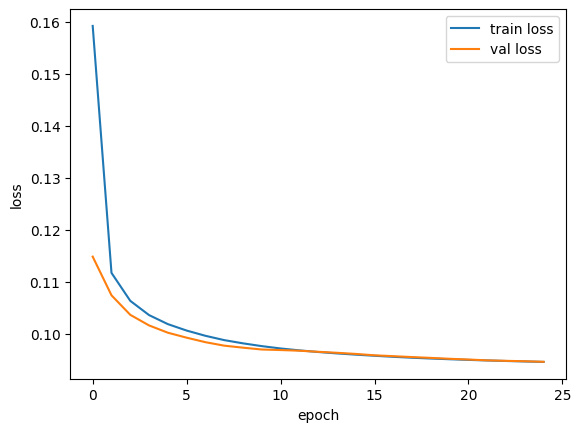

In [12]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [13]:
denoised_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


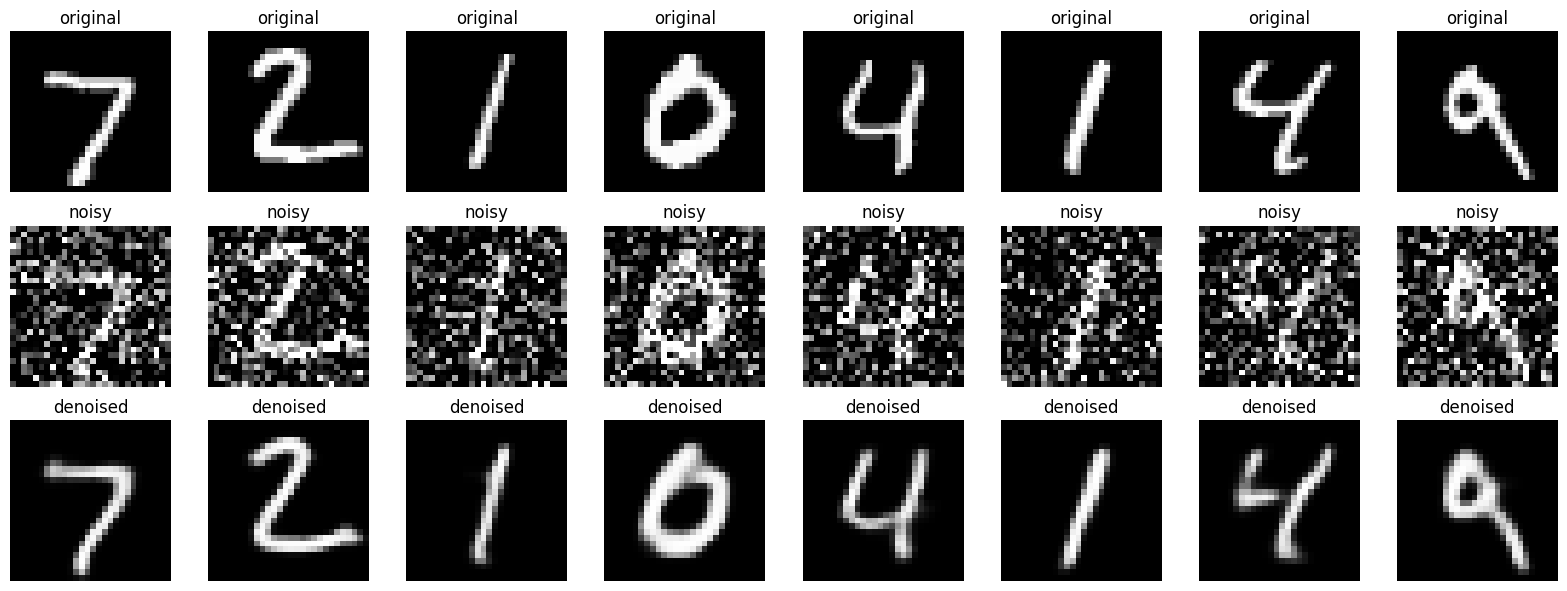

In [14]:
n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title('original')
    plt.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title('noisy')
    plt.axis('off')

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_imgs[i].squeeze(), cmap='gray')
    plt.title('denoised')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
mse = np.mean((x_test - denoised_imgs) ** 2)
print('reconstruction MSE on test set:', mse)

reconstruction MSE on test set: 0.010546557


### Observations

- The autoencoder was trained on gaussian noise (factor 0.5) added to MNIST digits, with clean images as target.
- After ~25 epochs the model is able to recover the digit shape reasonably well, though very thin strokes get slightly blurred out in the reconstruction.
- Val loss tracks train loss closely, no major overfitting seen with this small conv autoencoder.
- Increasing noise_factor beyond ~0.7 starts to noticeably hurt reconstruction quality since some digit strokes get fully buried in noise.
- Using MaxPooling + UpSampling keeps the model lightweight, could probably get sharper reconstructions with strided conv/transposed conv instead of upsampling, or a deeper bottleneck.
- Binary cross-entropy worked fine here since pixel values are in [0,1] and roughly bimodal (background vs stroke), but MSE loss could be tried too for comparison.